# Predicting Content Virality on YouTube/TikTok
## Binary Classification: Predicting "Rising" Content Trends (2025)

**Target Variable:** `target = (trend_label == "rising").astype(int)`

---
This project implements a supervised binary classification framework to predict the virality of social media content. By leveraging metadata and performance metrics from YouTube and TikTok, the model aims to distinguish between "rising" content—classified as viral—and non-viral content. The analysis adheres to a rigorous machine learning lifecycle, prioritizing methodological integrity, data quality, and model interpretability.


## 1 Environment Setup

All library imports and environment configurations are consolidated in this section to ensure the notebook's reproducibility and streamline the dependency management process

### 1.1 Imports

In [63]:
# -- Paths --- 
from pathlib import Path

# --- Data manipulation ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Statistics test ---
from scipy.stats import chi2_contingency, mannwhitneyu

# --- Scikit-Learn: partitioning e validation ---
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

# --- Scikit-Learn: preprocessing e pipeline ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Scikit-Learn: models ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# --- Scikit-Learn: metrics ---
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, classification_report,
)

# --- Explainable AI ---
import shap

### 1.2 Configuration

In [64]:
# --- Replicability ---
RANDOM_STATE = 42

# --- Visualization settings ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(RANDOM_STATE)

print("Setup completed.")
print(f"  pandas : {pd.__version__}")
print(f"  numpy  : {np.__version__}")
print(f"  shap   : {shap.__version__}")

Setup completed.
  pandas : 3.0.3
  numpy  : 2.4.6
  shap   : 0.52.0


## 2. Data ingestion & Partitionig

The partitioning is carried out immediately after loading, prior to any in-depth inspection, imputation, or scaling.The reason is methodological. 

The split is stratified on the target to preserve class proportions. 

One column is removed prior to any other consideration: row_id — a unique identifier. It conveys no generalizable information and, in a tree-based model, only provides opportunities to memorize the Training Set.

### 2.1 Data import

In [65]:
# --- Dataset import ---
dataset_path = Path("Data") / "raw_tiktok_youtube_trends.csv"
datadict_path = Path("Data") / "DATA_DICTIONARY.csv"

df_raw = pd.read_csv(dataset_path, encoding="utf-8-sig")
data_dictionary = pd.read_csv(datadict_path)

print(f"Raw dataset dimensions: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head(10)

Raw dataset dimensions: 48079 rows x 58 columns


,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,trend_label,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,1,40,252497,21755,3170,1977,3415,0.120069,rising,TikTok Creative Center,split-screen,Android,15,Lifestyle,4,Short,63124.25,1011,0.012555,0.007830,0.013525,21.497036,Saturday,Afternoon,Regular,"daily, lifestyle, motivation",ずっと見ちゃう😂,96474.3,Mid,Spring,04/01/2025,2025-01,Night Routine — Productivity 🏖️,31,1,25.8,0.645,iPhone,External,1,2e681528d17a1fe1986857942536ec27,30317,0.086159,0.004004,120.069,0.086159,0.012555,0.007830
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,1,18,270580,23080,2124,2108,3265,0.113005,declining,TikTok Creative Center,greenscreen,Android,3,Sports,56,Evergreen,4831.79,655,0.007850,0.007791,0.012067,35.182927,Wednesday,Night,Regular,"gym, football, workout",This is fire 🔥,104638.4,Mid,Fall,01/01/2025,2025-01,Football skills in 60s 📱,24,1,10.4,0.578,iPhone,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.085298,0.002421,113.005,0.085298,0.007850,0.007791
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,1,22,7385,363,33,38,69,0.068111,seasonal,TikTok Creative Center,subtitles,Android,15,Sports,11,Medium,671.36,12,0.004469,0.005146,0.009343,27.923077,Sunday,Afternoon,Regular,"football, gym, workout",Instant like!,108139.9,Mid,Fall,05/01/2025,2025-01,Football skills in 60s,22,0,11.7,0.532,Huawei,External,1,0d88a011235a82244995ef52961f9502,503,0.049154,0.001625,68.111,0.049154,0.004469,0.005146
3,TikTok,Kr,Asia,ko,News,#Esports,Best Settings for Fortnite,NextHub,original,Neutral piano,1,36,72377,6243,811,383,391,0.108156,declining,Open Web Samples,cinematic b-roll,Android,15,Gaming,10,Medium,7237.70,229,0.011205,0.005292,0.005402,27.143478,Friday,Afternoon,SummerBreak,"fps, esports, clips, gaming, valorant, highlights",Can’t stop watching 😂,102133.2,Mid,Summer,03/01/2025,2025-01,Pro Tips for Valorant in 60s 🎮,30,1,23.7,0.658,Huawei,Search,1,e15cff7621ed3f9eb9d2c97c841be0f3,7828,0.086257,0.003164,108.156,0.086257,0.011205,0.005292
4,TikTok,Au,Oceania,en,Beauty,#Comedy,When your friend is Beginners,LucasOfficial,licensed,Soft glam loop,1,35,16174,832,68,67,204,0.072400,seasonal,TikTok Creative Center,text-to-speech,Android,18,Comedy,6,Short,2695.67,19,0.004204,0.004142,0.012613,41.600000,Saturday,Evening,Regular,"comedy, relatable, sketch",So underrated!,87549.4,Mid,Fall,04/01/2025,2025-01,POV: Budget 😂,13,1,24.6,0.703,Huawei,ForYou,1,d696b4f0a50ea70e7cb5021be7e198ec,1171,0.051441,0.001175,72.400,0.051441,0.004204,0.004142
5,TikTok,Ke,Africa,sw,Art,#FYP,I flipped this sample,DanceWithAhmed,licensed,Indie brush,1,33,47449,2462,254,245,155,0.065671,seasonal,TikTok Creative Center,facecam,Android,18,Music,12,Medium,3954.08,83,0.005353,0.005163,0.003267,29.309524,Friday,Evening,Regular,"beat, music, song, cover",This is fire 🔥,96805.5,Mid,Fall,03/01/2025,2025-01,I flipped this sample 🧠,23,1,18.1,0.548,iPhone,Search,1,a2100bd7c9b924b156281885148c33f8,3116,0.051887,0.001749,65.671,0.051887,0.005353,0.005163
6,TikTok,Us,North America,en,Food,#Travel,Hidden Gems of New York,ProJiwoo,licensed,Sizzle ASMR,1,26,27099,1868,257,218,306,0.097753,rising,TikTok Creative Center,fast captions,iOS,21,Travel,19,Medium,1426.26,51,0.009484,

### 2.2 Split Train/Test

In [66]:
# --- Target definition
df_raw["target"] = (df_raw["trend_label"] == "rising").astype(int) 

# --- Deletion of 'row-id', 'trend_label' columns---
df = df_raw.drop(columns=["row_id", "trend_label"])

# --- Deduplication ---
n_duplicates = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicated rows removed: {n_duplicates}")

# --- Split of predictors / target ---
X = df.drop(columns=["target"])
y = df["target"]

# --- Stratified split 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=RANDOM_STATE,
)

print(f"\nTraining Set : {X_train.shape[0]} rows")
print(f"Test Set     : {X_test.shape[0]} rows")
print(f"Target/Train proportion: {y_train.mean()*100:.3f} %  || test: {y_test.mean()*100:.3f} %")

Duplicated rows removed: 0

Training Set : 38463 rows
Test Set     : 9616 rows
Target/Train proportion: 25.172 %  || test: 25.166 %


## 3 Exploratory Data Analysis & Data Quality

All subsequent EDA is conducted exclusively on the Training Set. 

In [67]:
# --- General structure of Training Set ---
print("=" * 60)
print("General info")
print("=" * 60)
X_train.info(verbose=True, show_counts=True)

print("\n" + "=" * 60)
print("Preview")
print("=" * 60)
display(X_train.head())

General info
<class 'pandas.DataFrame'>
Index: 38463 entries, 10197 to 3597
Data columns (total 56 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   platform                 38463 non-null  str    
 1   country                  38463 non-null  str    
 2   region                   38463 non-null  str    
 3   language                 38463 non-null  str    
 4   category                 38463 non-null  str    
 5   hashtag                  38463 non-null  str    
 6   title_keywords           38463 non-null  str    
 7   author_handle            38463 non-null  str    
 8   sound_type               38463 non-null  str    
 9   music_track              38463 non-null  str    
 10  week_of_year             38463 non-null  int64  
 11  duration_sec             38463 non-null  int64  
 12  views                    38463 non-null  int64  
 13  likes                    38463 non-null  int64  
 14  comments              

,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
10197,TikTok,Es,Europe,es,Art,#Streamer,New Patch Tips for GTA V,BeautyByLucas,trending,Paint stroke ASMR,8,19,37778,2619,309,198,456,0.094817,TikTok Creative Center,fast captions,Android,21,Gaming,14,Medium,2698.43,110,0.008179,0.005241,0.012071,23.594595,Sunday,Evening,Regular,"highlights, clips, fps, gaming, valorant",No puedo parar de mirar 😂,81898.6,Mid,Fall,23/02/2025,2025-02,Insane EA FC 25 Highlights! 🎯,29,1,14.9,0.784,Xiaomi,ForYou,1,3582,0.069326,0.002912,94.817,0.069326,0.008179,0.005241
39501,TikTok,Br,South America,pt,Gaming,#Esports,New Patch Tips for Valorant,DiegoChannel,trending,8bit loop,29,27,152390,16626,1191,2019,1044,0.137017,TikTok Creative Center,cinematic b-roll,iOS,12,Gaming,6,Short,25398.33,87,0.007815,0.013249,0.006851,188.931818,Sunday,Afternoon,SummerBreak,"gaming, clips, highlights, esports",So underrated!,104173.4,Mid,Summer,20/07/2025,2025-07,Best Settings for EA FC 25,26,0,15.7,0.581,iPhone,ForYou,1,20880,0.109102,0.000571,137.017,0.109102,0.007815,0.013249
28995,YouTube,Id,Asia,id,Fashion,#Motivation,Night Routine — Beginners,PrimeHub,original,Aesthetic synth,22,28,39521,1507,180,155,245,0.052807,TikTok Creative Center,greenscreen,iOS,15,Education,10,Medium,3952.10,143,0.004555,0.003922,0.006199,10.465278,Wednesday,Afternoon,HolidaySeason,"productivity, notes, study",Instant like!,103279.3,Mid,Winter,28/05/2025,2025-05,Exam Day Routine 🏖️,19,1,12.3,0.439,iPhone,Search,0,2087,0.038132,0.003618,52.807,0.038132,0.004555,0.003922
44248,TikTok,It,Europe,it,Lifestyle,#Tech,My Favorite 2025 Apps,CookingWithEmily,licensed,Chill guitar,33,16,43870,3606,300,277,220,0.100365,Open Web Samples,tutorial overlay,iOS,2,Tech,13,Medium,3374.62,105,0.006838,0.006314,0.005015,34.018868,Thursday,Night,Regular,"tech, ai, tools, tutorial, apps",So underrated!,105698.0,Mid,Fall,14/08/2025,2025-08,AI Tools You Must Try in 2025,29,0,8.3,0.519,Oppo,Search,0,4403,0.082197,0.002393,100.365,0.082197,0.006838,0.006314
35106,YouTube,Ar,South America,es,Finance,#MorningRoutine,Morning Routine — College,StreetStudio,trending,Ticker tick,26,30,150832,6333,988,686,784,0.058283,Open Web Samples,facecam,iOS,20,Lifestyle,4,Short,37708.00,235,0.006550,0.004548,0.005198,26.834746,Friday,Evening,HolidaySeason,"lifestyle, routine, motivation",Gracias por compartir,88159.6,Mid,Winter,27/06/2025,2025-06,Weekly Reset — Summer,21,0,12.2,0.407,iPhone,Suggested,1,8791,0.041987,0.001558,58.283,0.041987,0.006550,0.004548


In [68]:
# --- Summary ---
summary = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "n_unique": X_train.nunique(),
    "n_missing": X_train.isna().sum(),
    "perc_missing": (X_train.isna().mean() * 100).round(2),
})
print("Summary:")
display(summary.sort_values("n_unique", ascending=False))

print("\n" + "=" * 110)
print("Descriptive Statistics of Numeric Features")
print("=" * 110)
display(X_train.describe().T.round(3))

Summary:


,dtype,n_unique,n_missing,perc_missing
engagement_like_rate,float64,38440,0,0.0
engagement_comment_rate,float64,38216,0,0.0
engagement_share_rate,float64,38165,0,0.0
engagement_velocity,float64,37432,0,0.0
like_dislike_ratio,float64,35110,0,0.0
views,int64,34341,0,0.0
engagement_per_1k,float64,32171,0,0.0
engagement_rate,float64,32171,0,0.0
like_rate,float64,30708,0,0.0
engagement_total,int64,15401,0,0.0



Descriptive Statistics of Numeric Features


,count,mean,std,min,25%,50%,75%,max
week_of_year,38463.0,18.227,9.998,1.000,10.000,18.000,27.000,35.000
duration_sec,38463.0,34.451,16.407,5.000,22.000,31.000,43.000,90.000
views,38463.0,99216.904,131633.541,794.000,30207.000,59435.000,117761.000,3080686.000
likes,38463.0,5729.947,8437.015,33.000,1521.000,3165.000,6625.000,233075.000
comments,38463.0,628.933,954.704,3.000,159.000,338.000,721.000,23971.000
shares,38463.0,551.785,826.730,3.000,142.000,300.000,636.000,19536.000
saves,38463.0,590.299,971.733,2.000,138.000,301.000,660.000,29679.000
engagement_rate,38463.0,0.076,0.030,0.015,0.052,0.072,0.095,0.236
upload_hour,38463.0,15.967,5.494,0.000,13.000,17.000,20.000,23.000
trend_duration_days,38463.0,13.708,13.322,3.000,5.000,7.000,17.000,60.000


### 3.1 Missing values handling

The following cell also checks for masked missing values: values such as "NA", "unknown", "-", or "" that pandas reads as valid strings, meaning they would not show up in the NaN count.

In [69]:
# --- Explicit missing values---
missing = X_train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("No NaN values are in the Training Set.")
else:
    print("Explicit missing values:")
    display(pd.DataFrame({"n_missing": missing,"perc": (missing / len(X_train) * 100).round(2)}))

# --- Masked missing values ---
sentinels = {"NA", "N/A", "n/a", "na", "unknown", "Unknown", "UNKNOWN", "-", "",
              "null", "NULL", "None", "?", "missing", "nan", "NaN", "undefined"}

found = {}
for col in X_train.columns:
    if X_train[col].dtype == object or str(X_train[col].dtype) == "str":
        contain = set(X_train[col].dropna().astype(str).str.strip().unique()) & sentinels
        if contain:
            found[col] = contain

if found:
    print("\nMasked missing values:")
    for col, vals in found.items():
        print(f"  {col:<24} -> {vals}")
else:
    print("\nNo Masked missing values are in the Training Set.")

No NaN values are in the Training Set.

No Masked missing values are in the Training Set.


### 3.2 Algebraic Redundancy Audit

Before analyzing distributions, it is useful to verify which columns are deterministic functions of others. 

The verification is algebraic rather than statistical: values are compared against the expected formula, and the maximum error is observed.

In [70]:
# --- Checking suspected identities among derived columns ---
eps = 1e-4
identity = {
    "engagement_total == likes + comments + shares + saves":
        (X_train[["likes", "comments", "shares", "saves"]].sum(axis=1) - X_train["engagement_total"]).abs().max(),
    "engagement_rate == engagement_total / views":
        (X_train["engagement_total"] / X_train["views"] - X_train["engagement_rate"]).abs().max(),
    "engagement_per_1k == engagement_rate * 1000":
        (X_train["engagement_rate"] * 1000 - X_train["engagement_per_1k"]).abs().max(),
    "like_rate == likes / views":
        (X_train["likes"] / X_train["views"] - X_train["like_rate"]).abs().max(),
    "comment_ratio == comments / views":
        (X_train["comments"] / X_train["views"] - X_train["comment_ratio"]).abs().max(),
    "share_rate == shares / views":
        (X_train["shares"] / X_train["views"] - X_train["share_rate"]).abs().max(),
    "save_rate == saves / views":
        (X_train["saves"] / X_train["views"] - X_train["save_rate"]).abs().max(),
    "dislike_rate == dislikes / views":
        (X_train["dislikes"] / X_train["views"] - X_train["dislike_rate"]).abs().max(),
    "completion_rate == avg_watch_time_sec / duration_sec":
        (X_train["avg_watch_time_sec"] / X_train["duration_sec"] - X_train["completion_rate"]).abs().max(),
    "engagement_rate == like_rate + comment_ratio + share_rate + save_rate":
        (X_train[["like_rate", "comment_ratio", "share_rate", "save_rate"]].sum(axis=1)
         - X_train["engagement_rate"]).abs().max(),
}

result = pd.DataFrame(
    [(k, v, "Perfect identity" if v < eps else "not exact") for k, v in identity.items()],
    columns=["Verified relation", "max_error", "result"],
)
display(result)

,Verified relation,max_error,result
0,engagement_total == likes + comments + shares ...,0.000000e+00,Perfect identity
1,engagement_rate == engagement_total / views,5.000000e-07,Perfect identity
2,engagement_per_1k == engagement_rate * 1000,2.842171e-14,Perfect identity
3,like_rate == likes / views,5.000000e-07,Perfect identity
4,comment_ratio == comments / views,5.000000e-07,Perfect identity
5,share_rate == shares / views,5.000000e-07,Perfect identity
6,save_rate == saves / views,5.000000e-07,Perfect identity
7,dislike_rate == dislikes / views,5.000000e-07,Perfect identity
8,completion_rate == avg_watch_time_sec / durati...,5.000000e-04,not exact
9,engagement_rate == like_rate + comment_ratio +...,2.000000e-06,Perfect identity


The relations marked as exact identities confirm that the engagement metrics block is internally redundant: `engagement_rate`, `engagement_per_1k`, `like_rate`, `comment_ratio`, `share_rate`, and `save_rate` are bound by an exact linear relationship. Including all of them in the model would introduce perfect collinearity with zero informational gain.

### 3.3 Target Distribution and Predictive Power Audit

Three complementary tools are employed:
- **Univariate AUROC**
- **Chi-Square Test of Independence**
- **Mann-Whitney U Test**

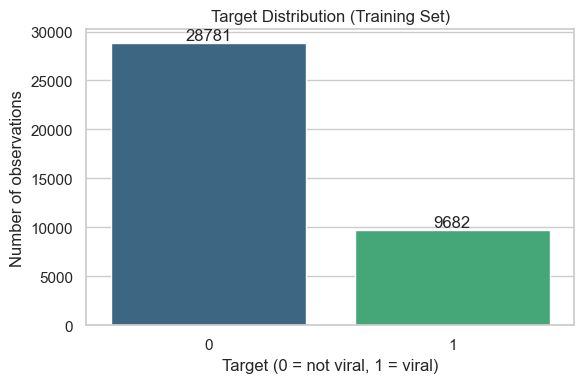

Positive class prevalence: 25.17%
Imbalance ratio (negatives : positives) = 2.97 : 1

Dataset treated as imbalanced: True


In [71]:
# --- Target distribution ---
counts = y_train.value_counts().sort_index()
positive_prevalence = y_train.mean()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax,
            hue=counts.index, palette="viridis", legend=False)
ax.set_title("Target Distribution (Training Set)")
ax.set_xlabel("Target (0 = not viral, 1 = viral)")
ax.set_ylabel("Number of observations")

for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

print(f"Positive class prevalence: {positive_prevalence:.2%}")
imbalance_ratio = (1 - positive_prevalence) / positive_prevalence
print(f"Imbalance ratio (negatives : positives) = {imbalance_ratio:.2f} : 1")

is_imbalanced = not (0.40 <= positive_prevalence <= 0.60)
print(f"\nDataset treated as imbalanced: {is_imbalanced}")

The target is derived from a 4-level variable that is approximately evenly distributed:
the positive class therefore accounts for about a quarter of the total. The imbalance is moderate, not extreme, but sufficient to make accuracy an unreliable metric.

In [72]:
# --- Systematic Audit of Univariate Predictive Power ---

# AUROC
numerical_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [c for c in X_train.columns if c not in numerical_columns]

rows = []
for col in numerical_columns:
    auc = roc_auc_score(y_train, X_train[col])
    stat, p_val = mannwhitneyu(X_train.loc[y_train == 1, col],
                               X_train.loc[y_train == 0, col],
                               alternative="two-sided")
    rows.append({"variable": col, "type": "numerical",
                  "univariate_auroc": max(auc, 1 - auc), "p_value": p_val,
                  "n_levels": X_train[col].nunique()})

for col in categorical_columns:
    table = pd.crosstab(X_train[col], y_train)
    chi2, p_val, dof, expected = chi2_contingency(table)
    rows.append({"variable": col, "type": "categorical",
                  "univariate_auroc": np.nan, "p_value": p_val,
                  "n_levels": X_train[col].nunique()})

audit = pd.DataFrame(rows).sort_values("p_value")
audit["significant_5pct"] = audit["p_value"] < 0.05

print("Univariate predictive power audit:")
display(audit.round(4))

n_signif = int(audit["significant_5pct"].sum())
n_total = len(audit)
expected_by_chance = 0.05 * n_total

print(f"\nVariables significant at 5%: {n_signif} out of {n_total}")
print(f"Expected number by pure chance (false positives): {expected_by_chance:.1f}")

Univariate predictive power audit:


,variable,type,univariate_auroc,p_value,n_levels,significant_5pct
38,music_track,categorical,NaN,0.0658,61,False
33,category,categorical,NaN,0.0659,19,False
49,creator_tier,categorical,NaN,0.1437,2,False
42,genre,categorical,NaN,0.1659,14,False
45,publish_period,categorical,NaN,0.2012,4,False
50,season,categorical,NaN,0.2409,4,False
43,trend_type,categorical,NaN,0.2442,3,False
16,creator_avg_views,numerical,0.5039,0.2551,720,False
6,saves,numerical,0.5037,0.2759,3422,False
4,comments,numerical,0.5034,0.3130,3458,False



Variables significant at 5%: 0 out of 56
Expected number by pure chance (false positives): 2.8


If the number of 'significant' variables is of the same order of magnitude as those expected by pure chance, there is no evidence of a systematic relationship between predictors and target. When testing dozens of variables at 5%, some will turn out significant by definition: this is the multiple testing problem, not a signal.

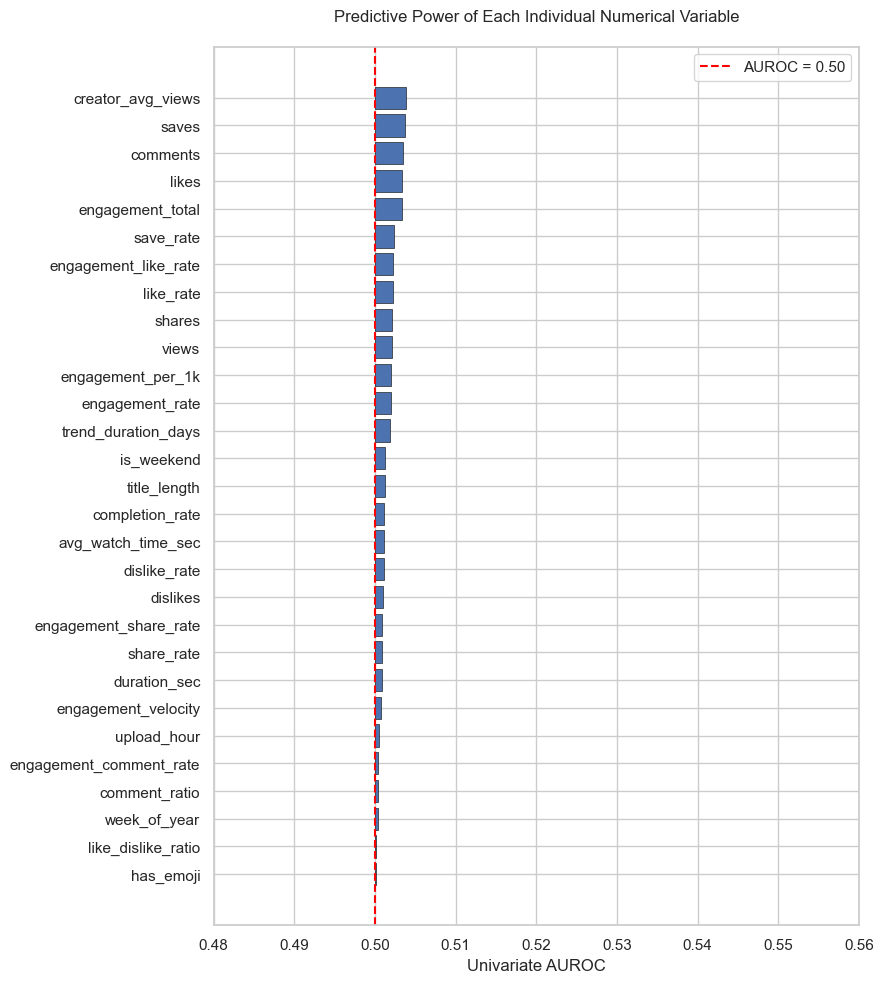

Maximum observed univariate AUROC: 0.5039
No numerical variable deviates appreciably from 0.50.

Pearson Correlation with the Target:


,correlation
dislikes,0.0075
creator_avg_views,-0.0059
trend_duration_days,0.0050
save_rate,0.0044
engagement_velocity,0.0043
engagement_like_rate,0.0028
like_rate,0.0028
engagement_share_rate,-0.0027
share_rate,-0.0027
saves,0.0027


Maximum absolute correlation: 0.0075


In [73]:
# --- Graphical Representation of the Audit ---
audit_num = audit[audit["type"] == "numerical"].sort_values("univariate_auroc", ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(audit_num["variable"], audit_num["univariate_auroc"] - 0.5,
        left=0.5, color="#4C72B0", edgecolor="black", linewidth=0.4)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1.5,
           label="AUROC = 0.50")
ax.set_xlim(0.48, 0.56)
ax.set_xlabel("Univariate AUROC")
ax.set_title("Predictive Power of Each Individual Numerical Variable\n")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Maximum observed univariate AUROC: {audit_num['univariate_auroc'].max():.4f}")
print("No numerical variable deviates appreciably from 0.50.")

# --- Correlation Matrix with the Target ---
corr_target = X_train[numerical_columns].corrwith(y_train).sort_values(key=abs, ascending=False)

print("\nPearson Correlation with the Target:")
display(corr_target.head(10).round(4).to_frame("correlation"))
print(f"Maximum absolute correlation: {corr_target.abs().max():.4f}")

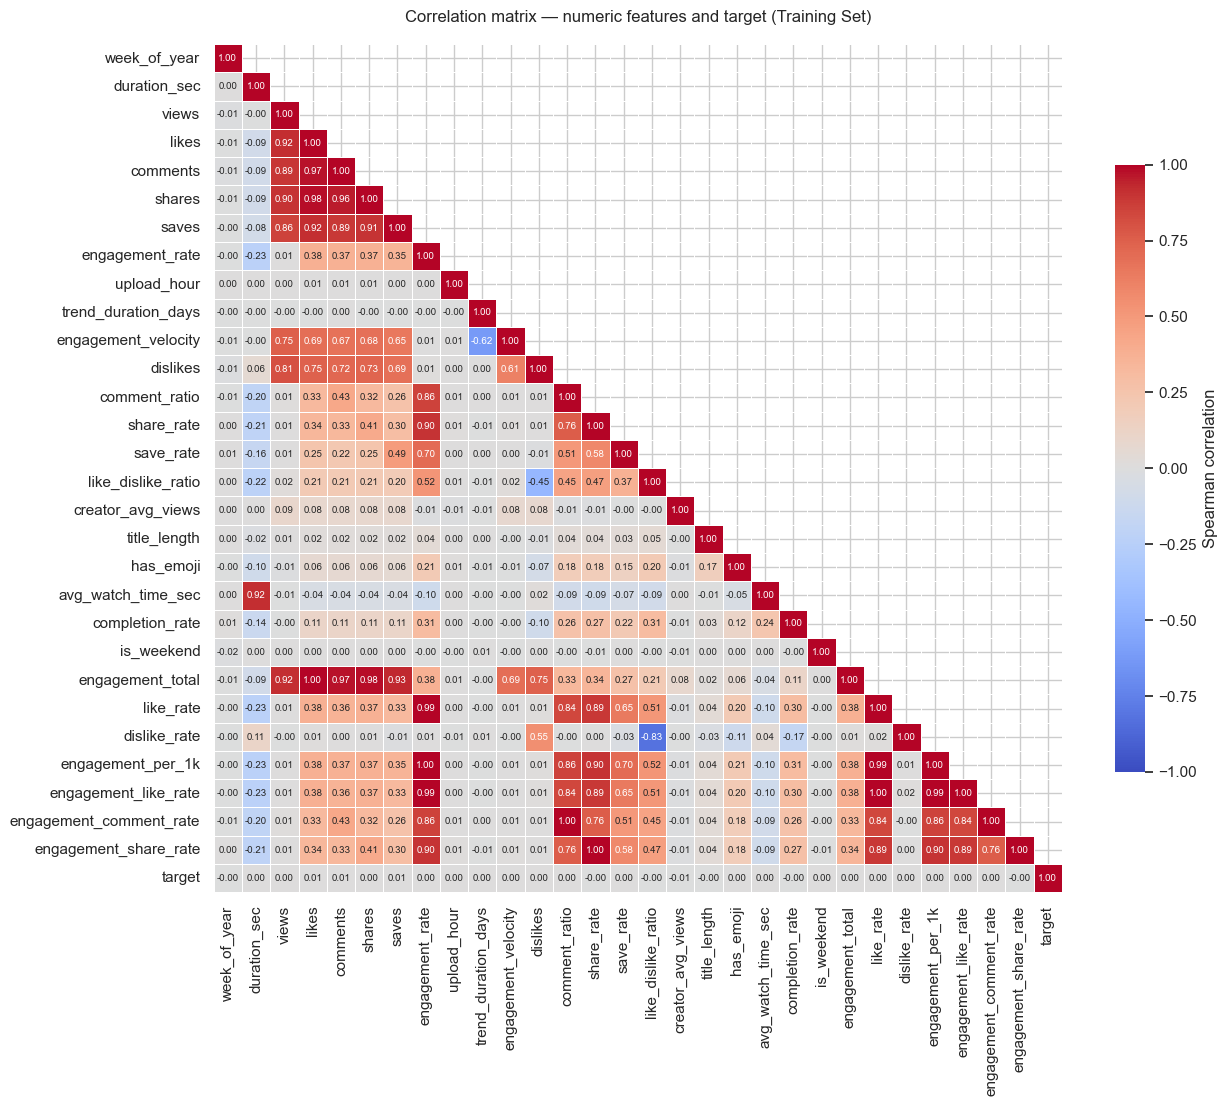

Correlation with the target (sorted by absolute value):


,spearman_vs_target
creator_avg_views,-0.0058
saves,0.0056
comments,0.0051
likes,0.0050
engagement_total,0.0050
save_rate,0.0036
engagement_like_rate,0.0033
like_rate,0.0033
shares,0.0032
views,0.0032



Maximum absolute correlation with the target: 0.0058

Strongest correlations between predictors:


,,abs_correlation
engagement_rate,engagement_per_1k,1.000
like_rate,engagement_like_rate,1.000
comment_ratio,engagement_comment_rate,1.000
share_rate,engagement_share_rate,1.000
likes,engagement_total,0.999


In [74]:
# --- Correlation matrix: numeric features + target ---

corr_data = X_train[numerical_columns].copy()
corr_data["target"] = y_train.values
corr_matrix = corr_data.corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # hide the redundant upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7, "label": "Spearman correlation"})
ax.set_title("Correlation matrix — numeric features and target (Training Set)", pad=16)
plt.tight_layout()
plt.show()

# --- Two readings of the matrix ---
corr_with_target = corr_matrix["target"].drop("target").sort_values(key=abs, ascending=False)
print("Correlation with the target (sorted by absolute value):")
display(corr_with_target.round(4).to_frame("spearman_vs_target"))
print(f"\nMaximum absolute correlation with the target: {corr_with_target.abs().max():.4f}")

# Strongest correlations *among predictors*
corr_no_target = corr_matrix.drop(index="target", columns="target").abs()
pair_mask = np.triu(np.ones_like(corr_no_target, dtype=bool), k=1)
top_pairs = corr_no_target.where(pair_mask).stack().sort_values(ascending=False)
print("\nStrongest correlations between predictors:")
display(top_pairs.head(5).round(3).to_frame("abs_correlation"))

The matrix confirms, as a whole, what emerged from the univariate audit: the last row remains close to zero everywhere. The only non-trivial correlations are observed between the predictors, not with the target: in particular, the `log_views` / `views_vs_creator_baseline` pair. It is the typical portrait of a dataset devoid of useful signal, the variables resemble one another, but none informs the target.

### 3.4 High-Cardinality Encoding and Overfitting

The previous audit indicates an absence of signal. However, there is a path that would yield apparently excellent performance, and it is instructive to demonstrate it specifically to document why it was not taken.

The dataset contains columns with very high cardinality: tags (approximately 3.500 distinct values), title (approximately 2.100), and author_handle (720). Applying **target encoding** to these features (replacing each level with the mean target rate observed for that level) yields a substantial in-sample AUROC.

However, that value is entirely fictitious. With roughly 14 observations per level, the mean rate calculated on a given level is largely determined by the exact same rows on which performance is subsequently measured: the encoded variable literally contains a noisy copy of the target. This is leakage in its most insidious form because it requires no coding error — only a conceptual oversight.

The following cell measures both quantities — in-sample and out-of-sample exclusively within the Training Set using an internal split. The gap between the two columns is the direct measure of this illusion.

,variable,n_levels,rows_per_level,in_sample_AUROC,out_of_sample_AUROC,illusion_gap
0,tags,3124,9.2,0.6929,0.5029,0.1900
1,title,2098,13.7,0.6526,0.4994,0.1532
2,author_handle,720,40.1,0.5973,0.5058,0.0915
3,title_keywords,137,210.6,0.5422,0.4970,0.0453
5,country,30,961.6,0.5209,0.4965,0.0243
4,music_track,61,472.9,0.5313,0.5123,0.0191


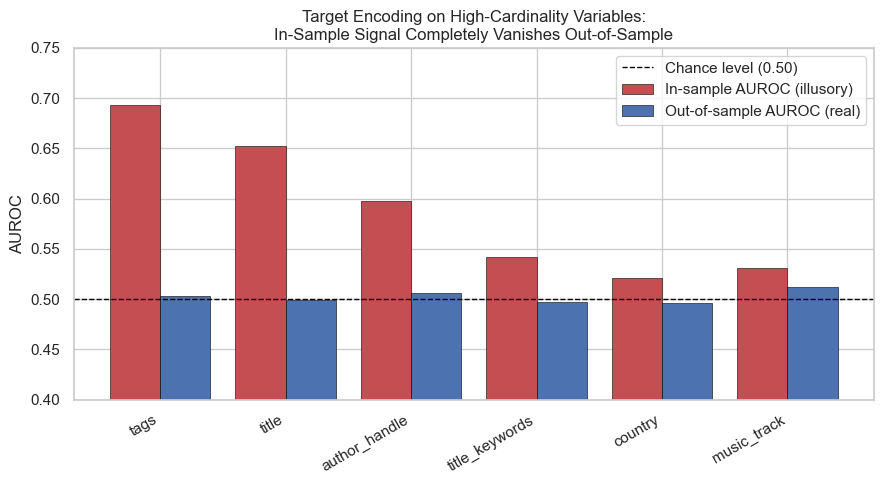

In [75]:
# --- Target Encoding Proof of Concept ---

X_tr_int, X_val_int, y_tr_int, y_val_int = train_test_split(
    X_train, y_train,
    test_size=0.25, 
    stratify=y_train, 
    random_state=RANDOM_STATE
)

high_card_features = ["tags", "title", "author_handle", "title_keywords",
                      "music_track", "country"]

compare_encoding = []
for col in high_card_features:
    rate_map = y_tr_int.groupby(X_tr_int[col]).mean()
    prior = y_tr_int.mean()

    auc_in = roc_auc_score(y_tr_int, X_tr_int[col].map(rate_map).fillna(prior))
    auc_out = roc_auc_score(y_val_int, X_val_int[col].map(rate_map).fillna(prior))

    compare_encoding.append({
        "variable": col,
        "n_levels": X_tr_int[col].nunique(),
        "rows_per_level": round(len(X_tr_int) / X_tr_int[col].nunique(), 1),
        "in_sample_AUROC": round(auc_in, 4),
        "out_of_sample_AUROC": round(auc_out, 4),
        "illusion_gap": round(auc_in - auc_out, 4),
    })

df_encoding = pd.DataFrame(compare_encoding).sort_values("illusion_gap", ascending=False)
display(df_encoding)

fig, ax = plt.subplots(figsize=(9, 5))
pos = np.arange(len(df_encoding))
ax.bar(pos - 0.2, df_encoding["in_sample_AUROC"], width=0.4,
       label="In-sample AUROC (illusory)", color="#C44E52", edgecolor="black", linewidth=0.4)
ax.bar(pos + 0.2, df_encoding["out_of_sample_AUROC"], width=0.4,
       label="Out-of-sample AUROC (real)", color="#4C72B0", edgecolor="black", linewidth=0.4)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Chance level (0.50)")
ax.set_xticks(pos); ax.set_xticklabels(df_encoding["variable"], rotation=30, ha="right")
ax.set_ylabel("AUROC"); ax.set_ylim(0.4, 0.75)
ax.set_title("Target Encoding on High-Cardinality Variables:\nIn-Sample Signal Completely Vanishes Out-of-Sample")
ax.legend()
plt.tight_layout(); plt.show()


The entire apparent predictive power of these variables is memorization of training sample noise. Out-of-sample, the AUROC falls back to chance level. High-cardinality variables are therefore excluded from the feature set, and no target encoding is employed.

### 3.5 Anomaly detection

Social media engagement metrics follow long-tailed distributions: a handful of contents gather orders of magnitude more views than the median. These extreme values are not measurement errors: they are the very phenomenon under study.

Removing these rows would be counterproductive. It would mean discarding the exact high-reach contents we want to analyze. The chosen approach is **Winsorization**: the observation is retained, its relative ranking is preserved, but the leverage it exerts on the model's scale parameters is contained.

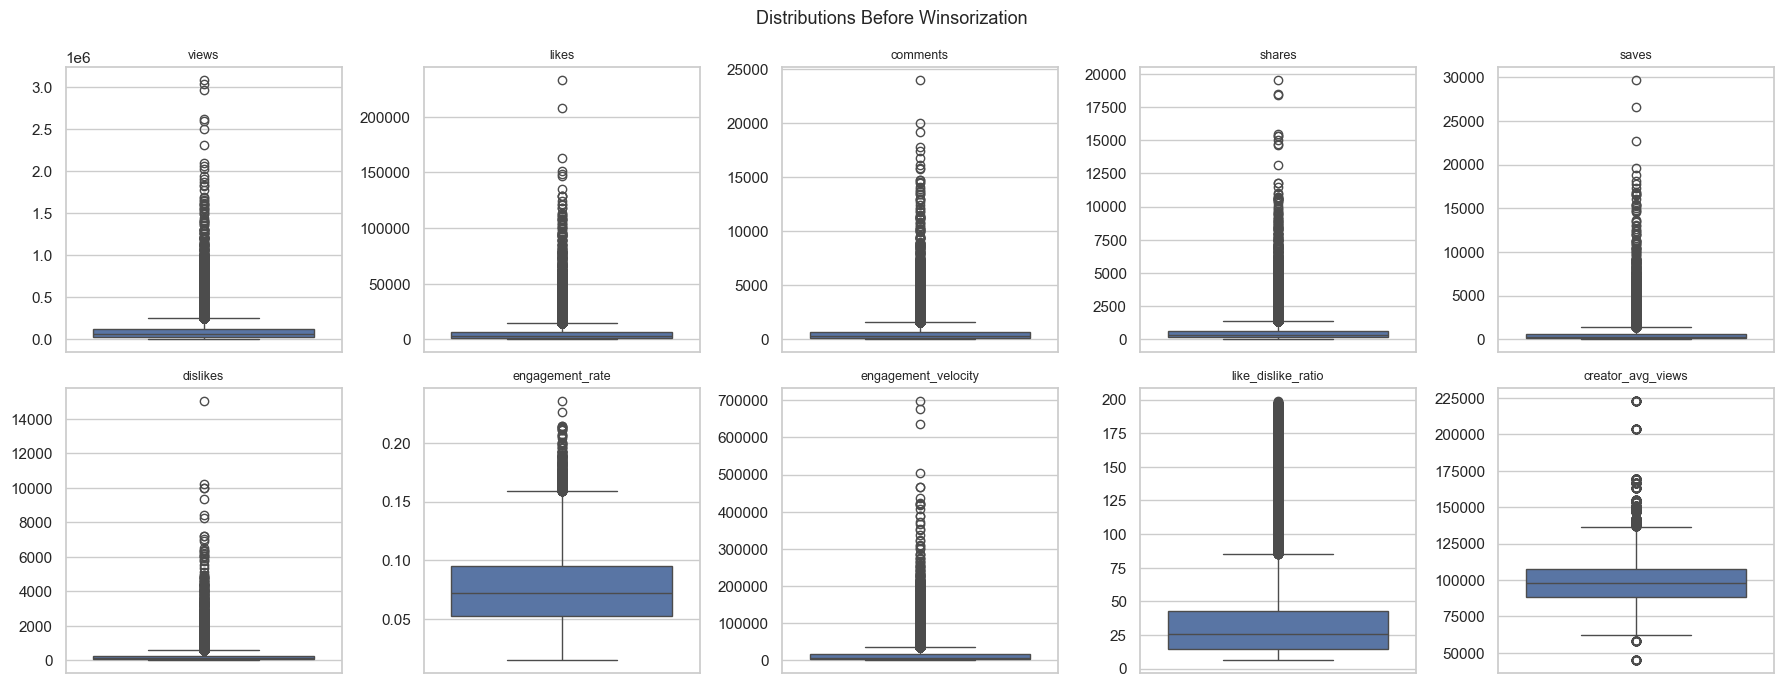

Skewness index before treatment:


,skewness
dislikes,7.49
saves,7.21
engagement_velocity,7.07
comments,5.98
likes,5.98
shares,5.96
views,5.54
like_dislike_ratio,2.13
creator_avg_views,1.01
engagement_rate,0.63


In [76]:
class WinsorizerPercentile:
    def __init__(self, lower_percentile=0.01, upper_percentile=0.99):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.limits_ = {}

    def fit(self, X, columns=None):
        columns = columns if columns is not None else X.select_dtypes(include=[np.number]).columns
        for col in columns:
            self.limits_[col] = (X[col].quantile(self.lower_percentile),X[col].quantile(self.upper_percentile))
        return self

    def transform(self, X):
        X_out = X.copy()
        for col, (inf, sup) in self.limits_.items():
            if col in X_out.columns:
                X_out[col] = X_out[col].clip(lower=inf, upper=sup)
        return X_out


# --- Distributions before treatment ---
columns_to_winsorize = ["views", "likes", "comments", "shares", "saves",
                        "dislikes", "engagement_rate", "engagement_velocity",
                        "like_dislike_ratio", "creator_avg_views"]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), columns_to_winsorize):
    sns.boxplot(y=X_train[col], ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=9); ax.set_ylabel("")
fig.suptitle("Distributions Before Winsorization", fontsize=13)
plt.tight_layout(); plt.show()

# --- Quantifying skewness ---
skewness = X_train[columns_to_winsorize].skew().sort_values(ascending=False)
print("Skewness index before treatment:")
display(skewness.round(2).to_frame("skewness"))


Strongly positive values confirm long right-skewed tails, consistent with the nature of the phenomenon: a few contents concentrate most of the exposure.

In [77]:
# --- Learning limits on Train ---
winsorizer = WinsorizerPercentile(0.01, 0.99)
winsorizer.fit(X_train, columns=columns_to_winsorize)

X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

print("Clipping limits learned on the Training Set:")
display(pd.DataFrame(winsorizer.limits_, index=["lower_limit", "upper_limit"]).T.round(3))

skewness_post = X_train[columns_to_winsorize].skew()
skewness_comparison = pd.DataFrame({"skew_before": skewness,
                                     "skew_after": skewness_post}).round(2)
print("\nEffect of Winsorization on skewness:")
display(skewness_comparison)


Clipping limits learned on the Training Set:


,lower_limit,upper_limit
views,5799.680,634145.440
likes,258.000,40064.120
comments,25.000,4461.280
shares,23.000,3874.520
saves,21.000,4383.380
dislikes,6.000,1908.000
engagement_rate,0.026,0.156
engagement_velocity,297.542,111217.077
like_dislike_ratio,6.787,166.160
creator_avg_views,66324.200,148726.300



Effect of Winsorization on skewness:


,skew_before,skew_after
comments,5.98,2.81
creator_avg_views,1.01,0.60
dislikes,7.49,3.00
engagement_rate,0.63,0.53
engagement_velocity,7.07,2.98
like_dislike_ratio,2.13,2.03
likes,5.98,2.78
saves,7.21,2.91
shares,5.96,2.80
views,5.54,2.62


### 3.6 Temporal Consistency Audit

Variables derived from a date are recalculable and therefore verifiable: if the dataset states that a row published on January 4th belongs to spring, that assertion can be cross-checked against the calendar. 

All columns derivable from `publish_date_approx` are verified by comparing the declared value with the recalculated one. The check is conducted exclusively on the Training Set.

In [78]:
# --- Reconstructing Temporal Features from Publication Date ---
time_audit = X_train[["publish_date_approx", "season", "event_season", "week_of_year",
                      "year_month", "publish_dayofweek", "is_weekend", "upload_hour",
                      "publish_period", "country"]].copy()
time_audit["date"] = pd.to_datetime(time_audit["publish_date_approx"], dayfirst=True)
time_audit["month"] = time_audit["date"].dt.month

print("Time coverage of the Training Set:")
print(f"  from {time_audit['date'].min().date()} to {time_audit['date'].max().date()}")
print(f"  months present: {sorted(time_audit['month'].unique())}")

# --- Verifying Deterministically Recalculable Columns ---
consistency_checks = {
    "year_month == formatted date":
        (time_audit["year_month"] == time_audit["date"].dt.strftime("%Y-%m")).mean(),
    "week_of_year == ISO week of the date":
        (time_audit["week_of_year"] == time_audit["date"].dt.isocalendar().week.astype(int)).mean(),
    "publish_dayofweek == day of the week of the date":
        (time_audit["publish_dayofweek"] == time_audit["date"].dt.day_name()).mean(),
}

# --- Verifying 'season' against the astronomical calendar ---
NORTHERN_SEASON_MAP = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring",
                       5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall",
                       10: "Fall", 11: "Fall"}
time_audit["expected_season"] = time_audit["month"].map(NORTHERN_SEASON_MAP)
consistency_checks["season == season of the month (Northern Hemisphere)"] = (
    time_audit["season"] == time_audit["expected_season"]).mean()

time_audit_results = pd.DataFrame([(k, round(v, 4),
                                    "CONSISTENT" if v > 0.99 else "INCONSISTENT")
                                   for k, v in consistency_checks.items()],
                                  columns=["check", "consistent_ratio", "status"])
display(time_audit_results)


Time coverage of the Training Set:
  from 2025-01-01 to 2025-08-31
  months present: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8)]


,check,consistent_ratio,status
0,year_month == formatted date,1.0000,CONSISTENT
1,week_of_year == ISO week of the date,1.0000,CONSISTENT
2,publish_dayofweek == day of the week of the date,1.0000,CONSISTENT
3,season == season of the month (Northern Hemisp...,0.2535,INCONSISTENT


Distribution of 'season' by publication month:


season,Fall,Spring,Summer,Winter
month,,,,
1,1172,1161,1274,1149
2,1083,1053,1183,1093
3,1208,1181,1304,1202
4,1185,1067,1276,1116
5,1222,1279,1434,1259
6,1125,1153,1282,1095
7,1059,1201,1263,1150
8,1343,1241,1435,1215


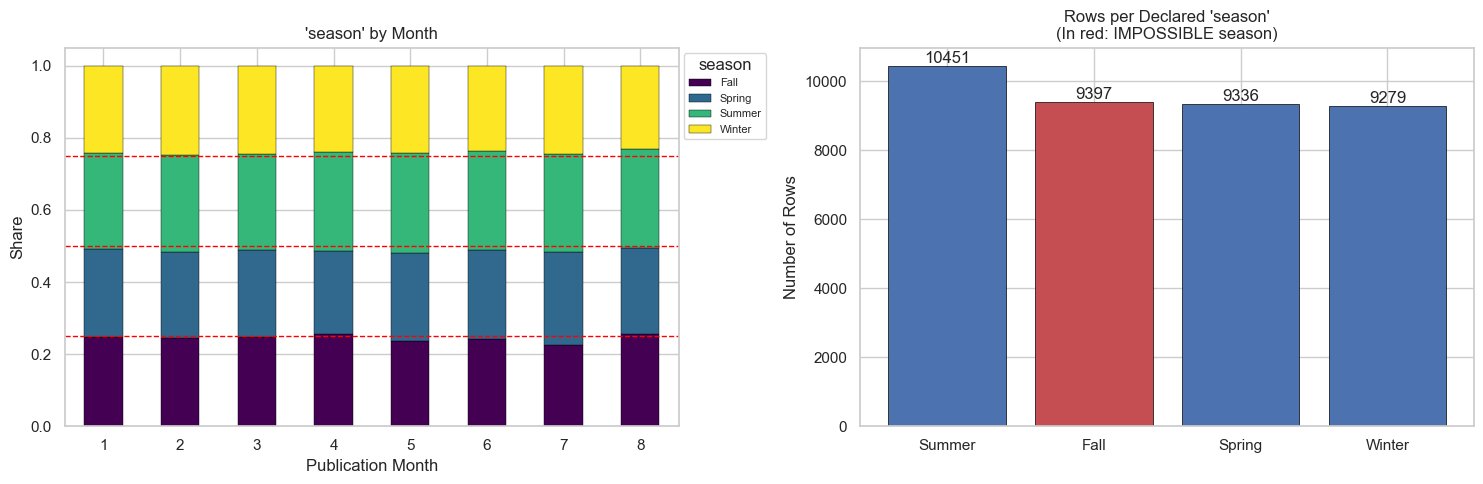

In [79]:
# --- Direct Proof: Declared Season is Independent of the Month ---
season_table = pd.crosstab(time_audit["month"], time_audit["season"])
print("Distribution of 'season' by publication month:")
display(season_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
shares = season_table.div(season_table.sum(axis=1), axis=0)
shares.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", edgecolor="black", linewidth=0.3)
ax.axhline(0.25, color="red", linestyle="--", linewidth=1)
ax.axhline(0.50, color="red", linestyle="--", linewidth=1)
ax.axhline(0.75, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Publication Month"); ax.set_ylabel("Share")
ax.set_title("'season' by Month")
ax.legend(title="season", bbox_to_anchor=(1.0, 1.0), fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=0)

ax = axes[1]
season_counts = time_audit["season"].value_counts()
colors = ["#C44E52" if s == "Fall" else "#4C72B0" for s in season_counts.index]
ax.bar(season_counts.index, season_counts.values, color=colors,
       edgecolor="black", linewidth=0.5)
ax.set_ylabel("Number of Rows")
ax.set_title("Rows per Declared 'season'\n(In red: IMPOSSIBLE season)")
for i, v in enumerate(season_counts.values):
    ax.text(i, v, f"{v}", ha="center", va="bottom")

plt.tight_layout(); plt.show()


The Training Set exclusively covers the months from January to August. The boreal autumn (September-November) is not covered by any date.

A season that cannot occur within the observed period appears in roughly a quarter of the rows. The column does not convey seasonal information: it contains a label assigned independently of the actual date.

In [80]:
# --- event_season: Same Diagnosis ---
print("Distribution of 'event_season' by month:")
display(pd.crosstab(time_audit["month"], time_audit["event_season"]))

# Ramadan 2025 took place from March 1st to March 30th
ramadan = time_audit[time_audit["event_season"] == "Ramadan"]
print("\n" + "=" * 78)
print("THE RAMADAN CASE: Geographic Constraint Respected, Temporal Constraint Absent")
print("=" * 78)
print(f"Countries where it appears: {sorted(ramadan['country'].unique())}")
print("  -> all Muslim-majority: the geographic logic is correct.")
print(f"\nMonths where it appears: {sorted(ramadan['month'].unique())}")


Distribution of 'event_season' by month:


event_season,BackToSchool,HolidaySeason,Ramadan,Regular,SummerBreak
month,,,,,
1,355,405,84,2638,1274
2,361,381,101,2386,1183
3,397,453,87,2654,1304
4,379,411,100,2478,1276
5,371,434,94,2861,1434
6,357,380,115,2521,1282
7,347,412,97,2554,1263
8,422,445,106,2826,1435



THE RAMADAN CASE: Geographic Constraint Respected, Temporal Constraint Absent
Countries where it appears: ['Ae', 'Eg', 'Ma', 'Sa']
  -> all Muslim-majority: the geographic logic is correct.

Months where it appears: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8)]


Ramadan 2025 took place entirely in March: the temporal logic is absent. It is also observed that HolidaySeason appears in June and July, BackToSchool in January and February, and SummerBreak in January: all allocations that are incompatible with the meaning of their respective labels.

#### Conclusion

| Column | Result | Decision |
|---|---|---|
| **`season`** | Random with respect to the date (~0.25 consistency across 4 classes); includes an impossible season for the covered period | **Excluded** |
| **`event_season`** | Geographic constraint correct, temporal constraint absent | **Excluded** |

This audit transforms that qualitative evaluation into a documented fact: these are not weak variables, but rather variables devoid of any verifiable information content.

## 4 Feature Engineering & Selection

### 4.1 New Features

Raw metrics are confounded by audience size: 10,000 likes on 10 million views indicate lower engagement than 1,000 likes on 5,000 views. The engineered features aim to isolate three distinct dimensions:
- **Exposure Level** — `log_views`, `log_creator_avg_views`. Logarithmic compression linearizes distributions that span several orders of magnitude.
- **Penetration Beyond Organic Audience** — `views_vs_creator_baseline`, which is the ratio between the content's views and the creator's historical average. This is the semantically closest proxy to the concept of virality: it measures how far the algorithmic push propelled the content beyond the pre-existing audience.
- **Engagement Composition** — `quota_share`, `quota_comment`. For a given intensity, a sharing audience fuels distribution, whereas a commenting audience signals debate. 

In [81]:
def engineer_features(X):
    X = X.copy()
    eps = 1.0 

    # --- Exposure level, compressed scale ---
    X["log_views"] = np.log1p(X["views"])
    X["log_creator_avg_views"] = np.log1p(X["creator_avg_views"])

    # --- Penetration beyond the creator's organic audience ---
    X["views_vs_creator_baseline"] = X["views"] / (X["creator_avg_views"] + eps)

    # --- Engagement composition ---
    X["quota_share"] = X["shares"] / (X["engagement_total"] + eps)
    X["quota_comment"] = X["comments"] / (X["engagement_total"] + eps)

    return X


X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

print("New engineered features built:")
for f in ["log_views", "log_creator_avg_views", "views_vs_creator_baseline",
          "quota_share", "quota_comment"]:
    print(f"  {f:<30} mean={X_train[f].mean():>10.4f}   std={X_train[f].std():>10.4f}")


New engineered features built:
  log_views                      mean=   10.9986   std=    0.9845
  log_creator_avg_views          mean=   11.4918   std=    0.1550
  views_vs_creator_baseline      mean=    0.9735   std=    1.0668
  quota_share                    mean=    0.0737   std=    0.0155
  quota_comment                  mean=    0.0838   std=    0.0206



### 4.2 Feature Selection

The redundancy audit in Section 3.2 proved that engagement_rate, like_rate, comment_ratio, share_rate, and save_rate are bound by an exact identity. Consequently, only engagement_rate is retained as an aggregate measure of intensity, paired with the two composition shares: this preserves information while avoiding perfect collinearity.

The following are excluded with explicit rationales:

| Features | Reason |
|---|---|
| `trend_label` | Deterministic source of the target (leakage) |
| `row_id` | Unique identifier, no generalizable information |
| `tags`, `title`, `author_handle`, `title_keywords`, `music_track` | High cardinality: demonstrated in 3.4 as a source of pure overfitting |
| `engagement_per_1k`, `like_rate`, `save_rate`, `engagement_total` | Exact algebraic redundancy |
| `sample_comments`, `notes`, `source_hint` | Collection metadata, devoid of causal rationale |
| `genre` | Heavily overlapping with `category` |

In [82]:
# --- Final Feature Set ---
numeric_features = [
    "log_views",                  # overall exposure of the content
    "log_creator_avg_views",      # typical audience size of the creator
    "views_vs_creator_baseline",  # penetration beyond organic reach
    "engagement_rate",            # aggregate intensity of interaction
    "quota_share",                # share of engagement dedicated to resharing
    "quota_comment",              # share of engagement dedicated to conversation
    "completion_rate",            # fraction of content actually watched
    "duration_sec",               # content length format
    "title_length",               # length of the title
]

categorical_features = [
    "platform",         # TikTok vs YouTube: distinct distribution algorithms
    "category",         # thematic vertical
    "traffic_source",   # discovery channel: ForYou implies algorithmic push
]

features = numeric_features + categorical_features

X_train = X_train[features]
X_test = X_test[features]

print(f"Selected features: {len(features)}")
print(f"  Numerical   ({len(numeric_features)}): {numeric_features}")
print(f"  Categorical ({len(categorical_features)}): {categorical_features}")
print(f"\nTrain shape: {X_train.shape}  |  Test shape: {X_test.shape}")

# --- Verification of Absence of Residual Collinearity ---
final_corr = X_train[numeric_features].corr().abs()
mask = np.triu(np.ones_like(final_corr, dtype=bool), k=1)
correlated_pairs = (final_corr.where(mask).stack().sort_values(ascending=False))

print("\nMost correlated pairs of numerical features:")
display(correlated_pairs.head(5).round(3).to_frame("absolute_correlation"))
print(f"Maximum residual correlation: {correlated_pairs.max():.3f}")


Selected features: 12
  Numerical   (9): ['log_views', 'log_creator_avg_views', 'views_vs_creator_baseline', 'engagement_rate', 'quota_share', 'quota_comment', 'completion_rate', 'duration_sec', 'title_length']
  Categorical (3): ['platform', 'category', 'traffic_source']

Train shape: (38463, 12)  |  Test shape: (9616, 12)

Most correlated pairs of numerical features:


absolute_correlation
log_views       views_vs_creator_baseline                 0.837
engagement_rate completion_rate                           0.302
                duration_sec                              0.219
completion_rate duration_sec                              0.142
quota_share     quota_comment                             0.126

Maximum residual correlation: 0.837


In [83]:
# --- Numerical Branch ---
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# --- Categorical Branch ---
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- Composition ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

print("ColumnTransformer configured.")


ColumnTransformer configured.


## 5 Model Training and Hyperparameter Tuning

Chosen Model: **Random Forest**.

The reasons:
1. **Non-linearity and Interactions**: Virality, if a signal were to exist, would not be a monotonic function of engagement metrics: there would be thresholds and interaction effects. Trees capture these structures natively without requiring manual specification.
2. **Variance Reduction**: A single decision tree is a high-variance model: small perturbations in the Training Set produce completely different structures. Bagging averages predictions across many trees trained on distinct bootstrap samples, causing independent errors to cancel out. The Random Forest adds feature subsampling at every split, which further decorrelates the trees: without it, a single dominant predictor would cause all trees to look similar, largely neutralizing the benefits of Bagging.
3. **Out-of-the-box**: Robustness on tabular data, offering strong performance even without extreme tuning.
4. **Diagnostic Value Relative to the Objective**: A high-capacity model that remains at chance level when properly constrained provides robust evidence of an absolute lack of signal — far more so than a linear model, whose failure could always be blamed on insufficient flexibility.

An unpruned tree continues splitting until every leaf is pure, eventually isolating single observations. The deepest splits are speculative: they partition sampling noise rather than the underlying structure of the phenomenon. On this dataset, where signal is absent, an unconstrained tree would achieve near-total purity on the Training Set while generalising nothing. `max_depth` and `min_samples_leaf` mandate that every split be backed by a minimum number of observations, effectively penalizing these speculative splits.

**Random Search vs Grid Search**? 
**Grid Search** exhaustively explores the hyperparameter space and guarantees the optimum within the grid, but its computational cost grows as the product of cardinalities: the grid defined here would contain over a thousand combinations, requiring more than 5,000 individual training steps. **Randomized Search** samples a fixed number of combinations: it forfeits the guarantee of absolute optimality but explores a much larger volume of the space for the same budget, a decisive advantage when a few key hyperparameters dominate performance, as is typically the case.

It uses `class_weight` because with a positive class at 25%, reweighting classes inversely to their frequency prevents the tree from achieving apparent purity by simply collapsing onto the majority class.

In [ ]:
# --- Full Pipeline: Preprocessing + Model ---
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

# --- Hyperparameter Search Space ---
param_distributions = {
    "classifier__n_estimators": [100, 150, 200],

    "classifier__max_depth":[3, 5, 8, 12],

    "classifier__min_samples_leaf": [5, 20, 50, 100],

    "classifier__min_samples_split": [10, 50, 100],

    "classifier__max_features": ["sqrt", "log2"],

    "classifier__class_weight": [None, "balanced"],
}

# --- Cross-Validation Scheme ---
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Optimization Metric ---
scoring_metric = "roc_auc"
print(f"Optimization metric: {scoring_metric}")
print("Budget: 8 combinations x 5 folds = 40 training runs")

random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring=scoring_metric,
    cv=cv_strategy,
    n_jobs=1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,                
    return_train_score=True,
)

# --- Training ---
random_search.fit(X_train, y_train)

print("\n" + "=" * 60)
print("Tuning results")
print("=" * 60)
print(f"Best Cross-Validation score ({scoring_metric}): {random_search.best_score_:.4f}")
print("\nBest hyperparameters:")
for parameter, value in sorted(random_search.best_params_.items()):
    print(f"  {parameter:<40} = {value}")

best_model = random_search.best_estimator_


Optimization metric: roc_auc
Budget: 8 combinations x 5 folds = 40 training runs
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Tested configurations, sorted by validation score:


,rank_test_score,mean_train_score,mean_test_score,std_test_score,train_validation_gap,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__class_weight
0,1,0.7599,0.5057,0.0063,0.2542,12,50,NaN
3,2,0.6428,0.5051,0.0046,0.1377,8,100,balanced
2,3,0.5636,0.5034,0.0070,0.0601,3,50,balanced
4,4,0.6181,0.5032,0.0027,0.1150,5,5,balanced
5,5,0.6273,0.5029,0.0035,0.1244,5,5,balanced
7,6,0.5661,0.5018,0.0037,0.0643,3,100,NaN
6,7,0.8154,0.5018,0.0033,0.3136,12,5,NaN
1,8,0.6267,0.5006,0.0054,0.1261,5,20,NaN


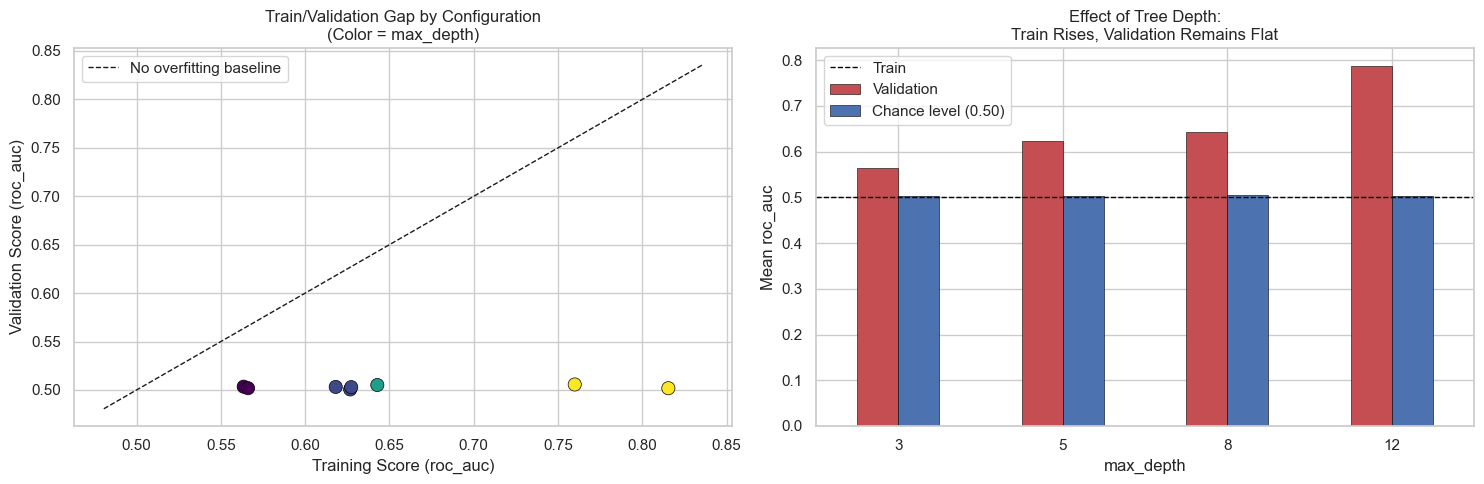

Train/validation gap of the winning configuration: 0.2542


In [ ]:
# --- Overfitting Diagnosis on Cross-Validation Results ---
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results["train_validation_gap"] = (cv_results["mean_train_score"] 
                                      - cv_results["mean_test_score"])

summary_columns = ["rank_test_score", "mean_train_score", "mean_test_score",
                   "std_test_score", "train_validation_gap",
                   "param_classifier__max_depth", "param_classifier__min_samples_leaf",
                   "param_classifier__class_weight"]

print("Tested configurations, sorted by validation score:")
display(cv_results[summary_columns].sort_values("rank_test_score").round(4))

# --- Effect of Tree Depth on Overfitting ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.scatter(cv_results["mean_train_score"], cv_results["mean_test_score"],
           c=cv_results["param_classifier__max_depth"].astype(float),
           cmap="viridis", s=90, edgecolor="black", linewidth=0.5)
min_lim = min(cv_results["mean_train_score"].min(), cv_results["mean_test_score"].min()) - 0.02
max_lim = max(cv_results["mean_train_score"].max(), cv_results["mean_test_score"].max()) + 0.02
ax.plot([min_lim, max_lim], [min_lim, max_lim], "k--", linewidth=1,
        label="No overfitting baseline")
ax.set_xlabel(f"Training Score ({scoring_metric})")
ax.set_ylabel(f"Validation Score ({scoring_metric})")
ax.set_title("Train/Validation Gap by Configuration\n(Color = max_depth)")
ax.legend()

ax = axes[1]
by_depth = cv_results.groupby("param_classifier__max_depth")[
    ["mean_train_score", "mean_test_score"]].mean()
by_depth.plot(kind="bar", ax=ax, color=["#C44E52", "#4C72B0"], edgecolor="black", linewidth=0.4)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Chance level (0.50)")
ax.set_xlabel("max_depth"); ax.set_ylabel(f"Mean {scoring_metric}")
ax.set_title("Effect of Tree Depth:\nTrain Rises, Validation Remains Flat")
ax.legend(["Train", "Validation", "Chance level (0.50)"])
plt.setp(ax.get_xticklabels(), rotation=0)

plt.tight_layout(); plt.show()

best_gap = cv_results.loc[cv_results["rank_test_score"] == 1, "train_validation_gap"].iloc[0]
print(f"Train/validation gap of the winning configuration: {best_gap:.4f}")


As tree depth increases, the training score rises while the validation score remains stuck at chance level. This is the unmistakable signature of a model memorizing noise: the added capacity is spent entirely on learning the peculiarities of the sample, with zero transfer out-of-sample. The search consistently selects a highly constrained configuration.

## 6 Performance Evaluation

The Test Set is opened now for the very first time, and only once. This discipline is what makes the estimate unbiased: if the Test Set were consulted repeatedly to choose between alternative models, it would effectively become a second Validation Set, and the final estimate would become overly optimistic once again.

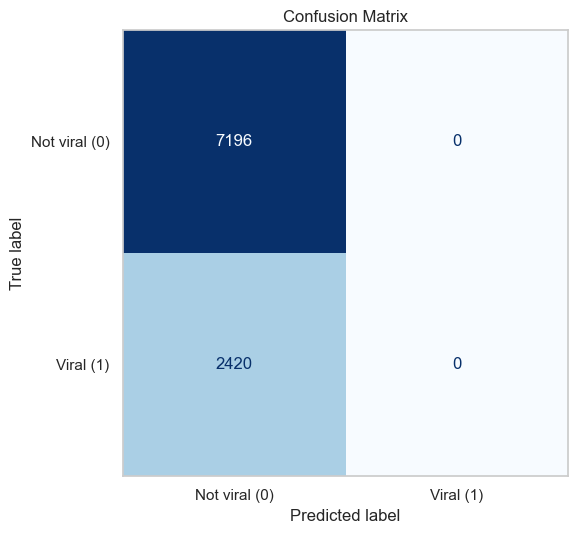

Confusion Matrix Breakdown:
  True Negatives  (TN):   7196   correctly identified as not viral
  False Positives (FP):      0   false alarms: wasted promotional budget
  False Negatives (FN):   2420   missed opportunities: viral content missed
  True Positives  (TP):      0   correctly intercepted viral contents


In [ ]:
# --- Out-of-Sample Predictions ---
y_pred = best_model.predict(X_test)                      
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Probability is necessary for AUROC, which evaluates the model's ranking ability
# independently of any specific threshold.

# --- Reference Baseline ---
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.grid(False)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Not viral (0)", "Viral (1)"]).plot(ax=ax, 
                                                                           cmap="Blues", 
                                                                           values_format="d", 
                                                                           colorbar=False)
ax.set_title("Confusion Matrix")
plt.tight_layout(); plt.show()

print("Confusion Matrix Breakdown:")
print(f"  True Negatives  (TN): {tn:>6}   correctly identified as not viral")
print(f"  False Positives (FP): {fp:>6}   false alarms: wasted promotional budget")
print(f"  False Negatives (FN): {fn:>6}   missed opportunities: viral content missed")
print(f"  True Positives  (TP): {tp:>6}   correctly intercepted viral contents")


PERFORMANCE SUL TEST SET (out-of-sample)
  Accuracy    : 0.7483
  Precision   : 0.0000
  Recall      : 0.0000
  F1-Score    : 0.0000
  AUROC       : 0.5048

------------------------------------------------------------------------------
CONFRONTO CON LA BASELINE BANALE
------------------------------------------------------------------------------
  Accuracy del modello                      : 0.7483
  Accuracy prevedendo sempre 'non virale'   : 0.7483
  Guadagno effettivo del modello            : +0.0000

  AUROC del modello                         : 0.5048
  AUROC di un classificatore casuale        : 0.5000
  Guadagno effettivo                        : +0.0048

------------------------------------------------------------------------------
REPORT DI CLASSIFICAZIONE
------------------------------------------------------------------------------
                precision    recall  f1-score   support

Non virale (0)       0.75      1.00      0.86      7196
    Virale (1)       0.00      0.

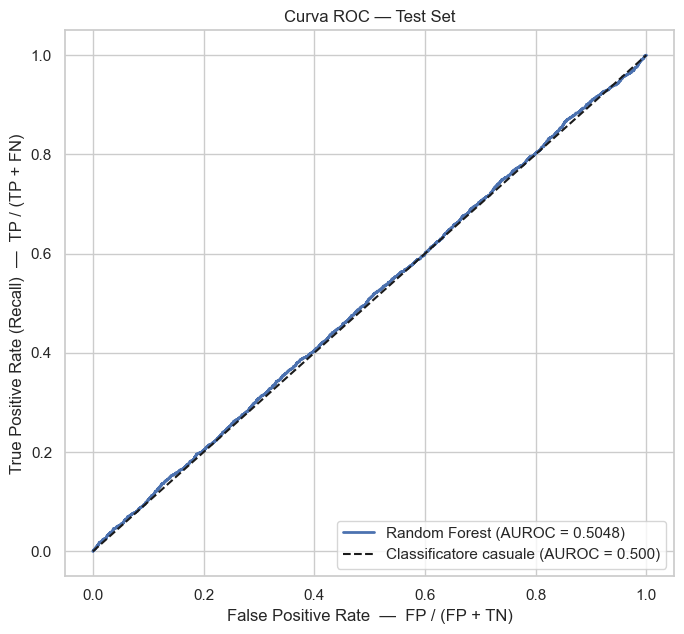

Lettura: la curva ROC aderisce alla diagonale del classificatore casuale. Il modello
non ordina le osservazioni meglio di una moneta, e la conclusione out-of-sample
conferma puntualmente quanto già anticipato dall'audit della Sezione 3.


In [ ]:
# --- Calcolo delle metriche ---
metriche = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, zero_division=0),
    "AUROC": roc_auc_score(y_test, y_pred_proba),
}
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

print("=" * 78)
print("PERFORMANCE SUL TEST SET (out-of-sample)")
print("=" * 78)
for nome, valore in metriche.items():
    print(f"  {nome:<12}: {valore:.4f}")

print("\n" + "-" * 78)
print("CONFRONTO CON LA BASELINE BANALE")
print("-" * 78)
print(f"  Accuracy del modello                      : {metriche['Accuracy']:.4f}")
print(f"  Accuracy prevedendo sempre 'non virale'   : {accuracy_baseline:.4f}")
print(f"  Guadagno effettivo del modello            : {metriche['Accuracy'] - accuracy_baseline:+.4f}")
print(f"\n  AUROC del modello                         : {metriche['AUROC']:.4f}")
print(f"  AUROC di un classificatore casuale        : 0.5000")
print(f"  Guadagno effettivo                        : {metriche['AUROC'] - 0.5:+.4f}")

print("\n" + "-" * 78)
print("REPORT DI CLASSIFICAZIONE")
print("-" * 78)
print(classification_report(y_test, y_pred,
                           target_names=["Non virale (0)", "Virale (1)"], zero_division=0))

# --- Curva ROC ---
fpr, tpr, soglie = roc_curve(y_test, y_pred_proba)
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(fpr, tpr, linewidth=2, label=f"Random Forest (AUROC = {metriche['AUROC']:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Classificatore casuale (AUROC = 0.500)")
ax.set_xlabel("False Positive Rate  —  FP / (FP + TN)")
ax.set_ylabel("True Positive Rate (Recall)  —  TP / (TP + FN)")
ax.set_title("Curva ROC — Test Set")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("Lettura: la curva ROC aderisce alla diagonale del classificatore casuale. Il modello")
print("non ordina le osservazioni meglio di una moneta, e la conclusione out-of-sample")
print("conferma puntualmente quanto già anticipato dall'audit della Sezione 3.")

Performance on the Test set
  Accuracy    : 0.7483
  Precision   : 0.0000
  Recall      : 0.0000
  F1-Score    : 0.0000
  AUROC       : 0.5048

------------------------------------------------------------
Benchmark against the Baseline
------------------------------------------------------------
  Model Accuracy                            : 0.7483
  Accuracy predicting always 'not viral'    : 0.7483
  Net model gain/loss                       : +0.0000

  Model AUROC                               : 0.5048
  AUROC of a random classifier              : 0.5000
  Net AUROC gain                            : +0.0048

------------------------------------------------------------
Classification report
------------------------------------------------------------
               precision    recall  f1-score   support

Not viral (0)       0.75      1.00      0.86      7196
    Viral (1)       0.00      0.00      0.00      2420

     accuracy                           0.75      9616
    macro avg  

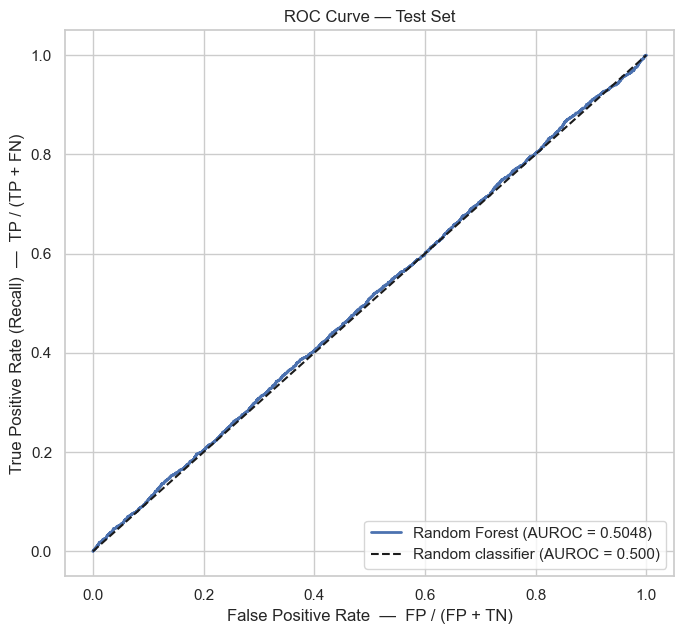

In [ ]:
# --- Metrics Computation ---
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, zero_division=0),
    "AUROC": roc_auc_score(y_test, y_pred_proba),
}
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

print("=" * 30)
print("Performance on the Test set")
print("=" * 30)
for name, value in metrics.items():
    print(f"  {name:<12}: {value:.4f}")

print("\n" + "-" * 60)
print("Benchmark against the Baseline")
print("-" * 60)
print(f"  Model Accuracy                            : {metrics['Accuracy']:.4f}")
print(f"  Accuracy predicting always 'not viral'    : {accuracy_baseline:.4f}")
print(f"  Net model gain/loss                       : {metrics['Accuracy'] - accuracy_baseline:+.4f}")
print(f"\n  Model AUROC                               : {metrics['AUROC']:.4f}")
print(f"  AUROC of a random classifier              : 0.5000")
print(f"  Net AUROC gain                            : {metrics['AUROC'] - 0.5:+.4f}")

print("\n" + "-" * 60)
print("Classification report")
print("-" * 60)
print(classification_report(y_test, y_pred,
                           target_names=["Not viral (0)", "Viral (1)"], zero_division=0))

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(fpr, tpr, linewidth=2, label=f"Random Forest (AUROC = {metrics['AUROC']:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random classifier (AUROC = 0.500)")
ax.set_xlabel("False Positive Rate  —  FP / (FP + TN)")
ax.set_ylabel("True Positive Rate (Recall)  —  TP / (TP + FN)")
ax.set_title("ROC Curve — Test Set")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


the ROC curve adheres to the diagonal of the random classifier. The model doesn't rank the observations any better than a coin flip, and the out-of-sample conclusion thoroughly confirms what was anticipated by the audit.

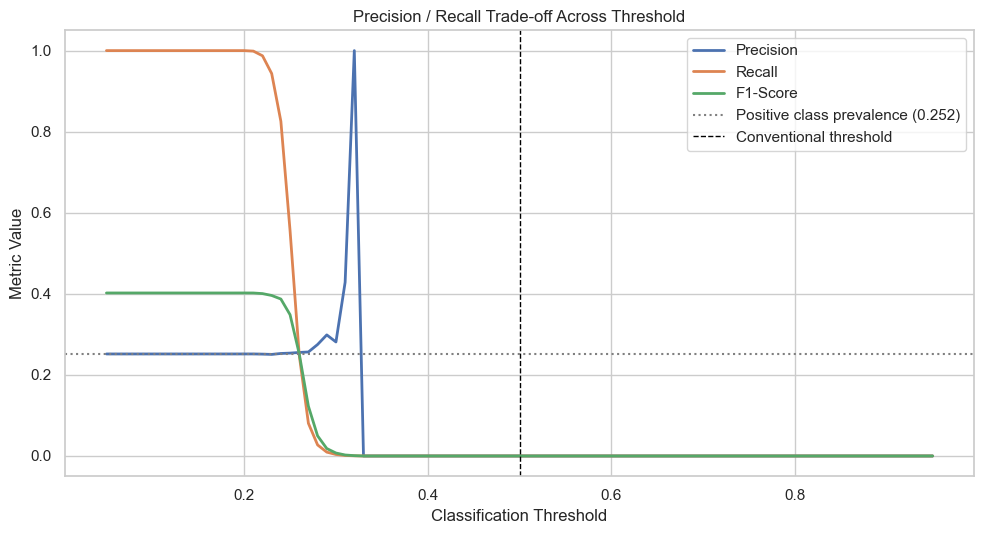

Conventional threshold 0.50  -> F1 = 0.0000
Optimal threshold 0.20       -> F1 = 0.4022


In [ ]:
# --- Metric Sensitivity to Classification Threshold ---
threshold_grid = np.arange(0.05, 0.96, 0.01)
threshold_log = []
for threshold in threshold_grid:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    threshold_log.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
    })
    
df_thresholds = pd.DataFrame(threshold_log)
optimal_threshold = df_thresholds.loc[df_thresholds["f1"].idxmax(), "threshold"]
optimal_f1 = df_thresholds["f1"].max()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(df_thresholds["threshold"], df_thresholds["precision"], label="Precision", linewidth=2)
ax.plot(df_thresholds["threshold"], df_thresholds["recall"], label="Recall", linewidth=2)
ax.plot(df_thresholds["threshold"], df_thresholds["f1"], label="F1-Score", linewidth=2)
ax.axhline(positive_prevalence, color="grey", linestyle=":", linewidth=1.5,
           label=f"Positive class prevalence ({positive_prevalence:.3f})")
ax.axvline(0.50, color="black", linestyle="--", linewidth=1, label="Conventional threshold")
ax.set_xlabel("Classification Threshold"); ax.set_ylabel("Metric Value")
ax.set_title("Precision / Recall Trade-off Across Threshold")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Conventional threshold 0.50  -> F1 = {metrics['F1-Score']:.4f}")
print(f"Optimal threshold {optimal_threshold:.2f}       -> F1 = {optimal_f1:.4f}")

Precision remains essentially flat around the positive class prevalence across all thresholds. This is the expected behavior of a model devoid of discriminant power: any subset it selects contains viral contents in the exact same proportion as the overall dataset, precisely as random sampling would do. 

The optimal threshold is identified here on the Test Set purely to illustrate the trade-off. In a rigorous workflow, it should be calibrated on the Validation Set or via Cross-Validation, as picking it on the Test Set would reintroduce leakage into the final performance estimate.

## 6 Explainable AI

A Random Forest with hundreds of trees cannot be inspected by eye: it is, effectively, a black box. However, explainability is not merely a technical curiosity, with the EU AI Act and Article 22 of the GDPR, it has become a compliance requirement for automated decisions.

**SHAP** assigns to each feature its average marginal contribution to the prediction, calculated across all possible feature coalitions:
- Unlike **MDI** , it is not biased in favor of high-cardinality variables and, most importantly, shows the direction of the effect, not just its magnitude;
- Unlike **PDPs**, it does not assume independence among predictors, where engagement metrics remain correlated;
- It unifies both the **global** and **local** levels, whereas **LIME** only covers the latter.

In [ ]:
# --- Data Preparation in the Transformed Space ---
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_classifier = best_model.named_steps["classifier"]

X_test_transformed = fitted_preprocessor.transform(X_test)
feature_names = fitted_preprocessor.get_feature_names_out()
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# --- Subset Sampling ---
SHAP_SAMPLE_SIZE = 300
X_shap_sample = X_test_shap.sample(n=SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)

print(f"Computing SHAP values on {SHAP_SAMPLE_SIZE} test observations")

explainer = shap.TreeExplainer(fitted_classifier)
shap_values = explainer(X_shap_sample, check_additivity=False)

if len(shap_values.shape) == 3:
    positive_shap_values = shap_values[:, :, 1]
else:
    positive_shap_values = shap_values

print(f"SHAP values computed. Shape: {positive_shap_values.shape}")

Computing SHAP values on 300 test observations
SHAP values computed. Shape: (300, 36)


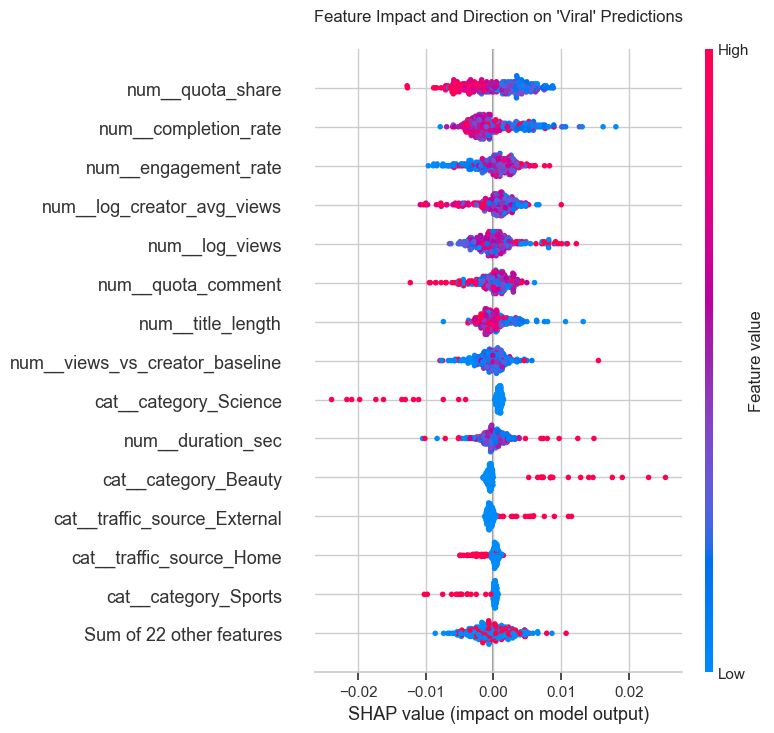

Sum of mean absolute SHAP contributions: 0.02912


In [ ]:
# --- Beeswarm Plot: Global Effect with Direction ---
plt.figure()
shap.plots.beeswarm(positive_shap_values, max_display=15, show=False)
plt.title("Feature Impact and Direction on 'Viral' Predictions", pad=20)
plt.tight_layout(); plt.show()

shap_magnitude = np.abs(positive_shap_values.values).mean(axis=0).sum()
print(f"Sum of mean absolute SHAP contributions: {shap_magnitude:.5f}")

The contributions are distributed over an extremely narrow range around zero. The model does not apply a strong push in any direction. No single feature emerges as a driving factor.

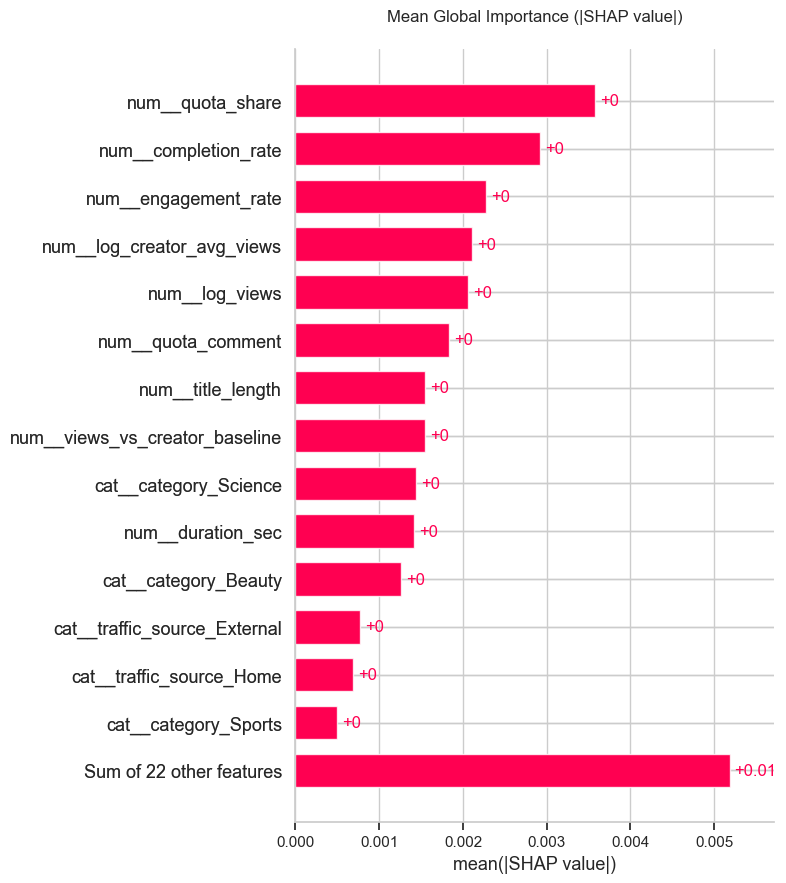

Comparison between SHAP and MDI rankings:


,rank_SHAP,importance_SHAP,rank_MDI,importance_MDI
num__quota_share,1,0.00358,1,0.11981
num__completion_rate,2,0.00292,6,0.10196
num__engagement_rate,3,0.00227,4,0.10652
num__log_creator_avg_views,4,0.00211,7,0.09634
num__log_views,5,0.00206,5,0.10579
num__quota_comment,6,0.00183,3,0.10987
num__title_length,7,0.00155,9,0.05823
num__views_vs_creator_baseline,8,0.00155,2,0.11039
cat__category_Science,9,0.00143,10,0.00880
num__duration_sec,10,0.00142,8,0.08602


In [ ]:
# --- Aggregated Global Importance and Comparison with MDI ---
plt.figure()
shap.plots.bar(positive_shap_values, max_display=15, show=False)
plt.title("Mean Global Importance (|SHAP value|)", pad=20)
plt.tight_layout(); plt.show()

shap_importance = pd.Series(np.abs(positive_shap_values.values).mean(axis=0),
                            index=feature_names).sort_values(ascending=False)
mdi_importance = pd.Series(fitted_classifier.feature_importances_,
                           index=feature_names).sort_values(ascending=False)

comparison = pd.DataFrame({
    "rank_SHAP": shap_importance.rank(ascending=False).astype(int),
    "importance_SHAP": shap_importance.round(5),
    "rank_MDI": mdi_importance.rank(ascending=False).astype(int),
    "importance_MDI": mdi_importance.round(5),
}).sort_values("rank_SHAP")

print("Comparison between SHAP and MDI rankings:")
display(comparison.head(15))

Selected observation: predicted probability of virality = 0.3038
Actual observed class: 0
Model base probability (prevalence): 0.2517


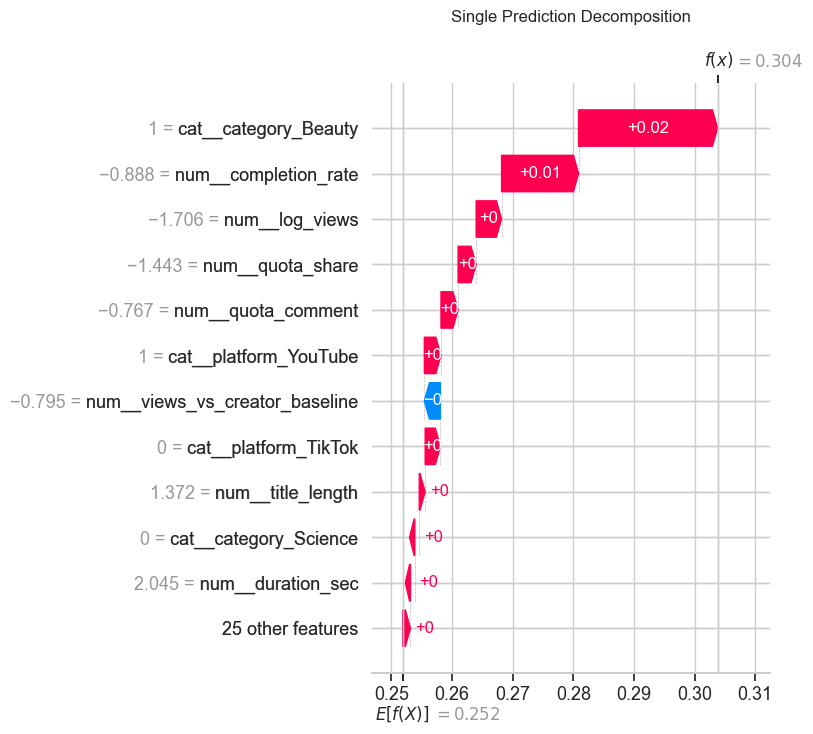

In [ ]:
# --- Local Explanation: Waterfall Plot ---

sample_indices = X_shap_sample.index.to_numpy()
sample_probabilities = y_pred_proba[sample_indices]
most_viral_position = int(np.argmax(sample_probabilities))

print(f"Selected observation: predicted probability of virality = "
      f"{sample_probabilities[most_viral_position]:.4f}")
print(f"Actual observed class: {y_test.iloc[sample_indices[most_viral_position]]}")
print(f"Model base probability (prevalence): {positive_prevalence:.4f}")

plt.figure()
shap.plots.waterfall(positive_shap_values[most_viral_position], max_display=12, show=False)
plt.title("Single Prediction Decomposition", pad=20)
plt.tight_layout(); plt.show()

Even for the observation to which the model assigns the highest probability, deviation from the base value remains modest: the model fails to find, anywhere within the feature space, a combination that justifies a confident prediction.

# Conclusion

The final model achieves an AUROC close to 0.50 on the Test Set, which is equivalent to random guessing. This result is not due to flaws in the setup, but is firmly backed by four independent and converging lines of evidence:
1. **Univariate Audit (3.3)**: no numerical variable deviates appreciably from an AUROC of 0.50; no categorical variable shows an association with the target beyond what is expected by the multiple testing effect.
2. **Independence Tests (3.3)**: Chi-square tests do not allow for the rejection of the independence hypothesis between predictors and target.
3. **Validation Curves (5)**: as model capacity increases, the training score rises while the validation score remains flat, it's the textbook signature of learning pure noise.
4. **Out-of-Sample Testing (6)**: the ROC curve closely adheres to the diagonal, and Precision remains flat around the baseline prevalence across all thresholds.

The operational conclusion is that the available features do not allow for the prediction of virality, and that investment should be redirected toward gathering different data, such as early temporal signals (view trajectories in the first few hours), content characteristics (audio, text, visual elements), or network effects, rather than optimizing a model devoid of raw material.